# Exercises
_Rijcklof Hofman s4792432_

In [1]:
import numpy as np
import scipy
import scipy.stats
import scipy.io
import matplotlib.pyplot as plt
from ipywidgets import interact
import ipywidgets as widgets
from tqdm import tqdm
import seaborn as sns
import pickle
import sys
import os
sys.path.append(os.path.abspath("code"))
from utils import download_data

sns.set_theme(context='notebook',style='white',font_scale=1.5,
              rc = {'axes.spines.top':False,'axes.spines.right':False})

# Download lesson data
download_data('https://surfdrive.surf.nl/s/z7mMiznEWOT0Iak')
#download_data('https://surfdrive.surf.nl/files/index.php/s/z7mMiznEWOT0Iak')

## Exercise 1 - simulating place cells
---
Use the code we build to simulate place cells in the lesson.

A - Explore what happens when you change the binning in the definition of the firing rate maps (`space_bins`). Make it coarser or broader. 

__Simulating place cells__


In [2]:
#A
track_length = 200. # the length of our linear track (eg in centimeter)
average_firing_rate = 5 # the peak firing rate, averaged across the population 
cell_size = 10 #The size of the place cells
n_cells = 100 # how many cells we are recording
seed = 42

def True_Place_Cells(average_firing_rate = 5,cell_size = 10,n_cells = 100,track_length = 200,seed=42):
    np.random.seed(seed)
    pf_centers = np.random.rand(n_cells) * track_length # the centers of the place fields for all cells drawn randomly with a uniform distribution on the track
    pf_size = np.random.gamma(cell_size, size=n_cells) # the size (width) of the place fields, drawn randomly from a gamma distribution 
    pf_rate = np.random.exponential(scale=average_firing_rate, size=n_cells) # the peak firing rate for each cell, drawn from an exponential distribution
    
    bins = np.arange(0., 200.)
    true_firing_rate_maps = np.zeros((n_cells, len(bins)))
    for i in range(n_cells):
        true_firing_rate_maps[i,:] = pf_rate[i] * np.exp(-((bins-pf_centers[i])**2)/(2*pf_size[i]**2))
    return true_firing_rate_maps,pf_centers,pf_size,pf_rate,bins

true_firing_rate_maps,pf_centers,pf_size,pf_rate,bins =  True_Place_Cells(average_firing_rate = average_firing_rate,cell_size = cell_size,n_cells = n_cells,track_length = track_length,seed=seed)


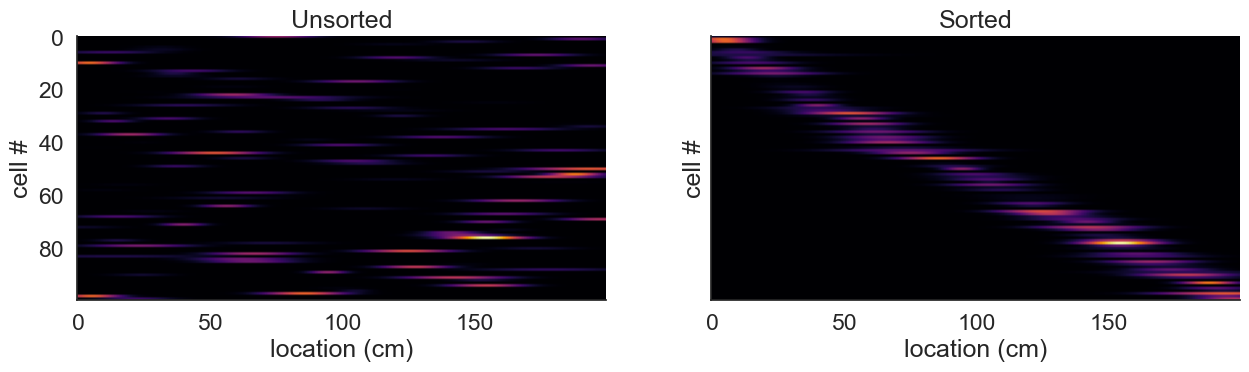

In [3]:
fig,axs = plt.subplots(ncols=2,figsize=(15,5),sharey=True)
#plt.figure(figsize=(10,5))
axs[0].imshow(true_firing_rate_maps, cmap='inferno')
axs[0].set_xlabel('location (cm)')
axs[0].set_ylabel('cell #')
axs[0].set_title('Unsorted')
#plt.colorbar()

ix = np.argsort(pf_centers)
axs[1].imshow(true_firing_rate_maps[ix,:], cmap='inferno')
axs[1].set_xlabel('location (cm)')
axs[1].set_ylabel('cell #')
axs[1].set_title('Sorted')
#axs[1].set_colorbar()
plt.show()
plt.close()

__Simulating the mouse__

In [4]:
n_runs = 20 
av_running_speed = 10 # the average running speed (in cm/s)
fps = 30 # the number of "video frames" per second 
av_wait_time = 15 # the average waiting time

def mouse_position(n_runs = 20,av_running_speed = 10,av_wait_time = 15,fps = 30,bins = np.arange(0., 200.),seed=42):
    np.random.seed(seed)
    running_speed_a = np.random.chisquare(av_running_speed, size=n_runs) # running speed in the two directions
    running_speed_b = np.random.chisquare(av_running_speed, size=n_runs) 
    
    stopping_time_a = np.random.chisquare(av_wait_time, size=n_runs) # the time the mouse will spend at the two ends of the track
    stopping_time_b = np.random.chisquare(av_wait_time, size=n_runs)
    
    x = np.array([])
    for i in range(n_runs):
        stop1 = np.ones((int(stopping_time_a[i]*fps),)) * 0.
        run_length = len(bins) * fps / running_speed_a[i]
        run1 = np.linspace(0., float(len(bins)-1), int(run_length))
        stop2 = np.ones((int(stopping_time_b[i]*fps),)) * (len(bins)-1.)
        run_length = len(bins) * fps / running_speed_b[i]
        run2 = np.linspace(len(bins)-1., 0., int(run_length))
        x = np.concatenate((x, stop1, run1, stop2, run2))
    t = np.arange(len(x))/fps

    return x,t

x,t = mouse_position(n_runs = n_runs,av_running_speed = av_running_speed,av_wait_time = av_wait_time,fps = fps,seed=seed)

In [5]:
def Sample_data(x,t,n_cells,true_firing_rate_maps,sampling_rate=10000.,noise_firing_rate=0.1):
    #sampling_rate = 10000.
    t_sampling = np.arange(0, t[-1], 1. / sampling_rate)
    x_sampling = np.floor(np.interp(t_sampling, t, x))
    #noise_firing_rate = 0.1 # the baseline noise firing rate
    spikes = []
    
    for i in tqdm(range(n_cells)):
        inst_rate = true_firing_rate_maps[i,x_sampling.astype(np.int32)] + noise_firing_rate
        spikes_loc = np.random.poisson(inst_rate/sampling_rate)
        sp = np.argwhere(spikes_loc)
        t_sp = t_sampling[sp]
        spikes.append(t_sp)
    
    spike_positions = [np.interp(s, t, x) for s in spikes]

    return spike_positions

spike_positions = Sample_data(x,t,n_cells,true_firing_rate_maps)

100%|██████████| 100/100 [00:48<00:00,  2.07it/s]


--------------------------------------------------
bin space = 0.5
--------------------------------------------------


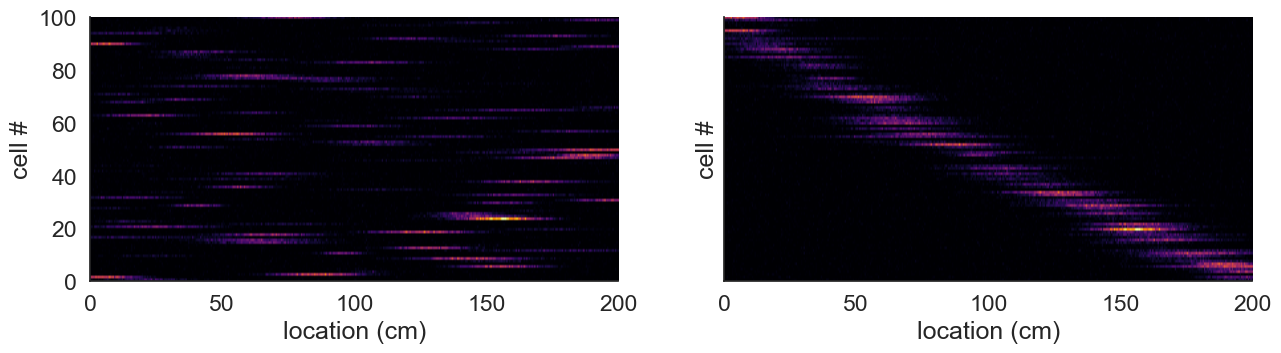

--------------------------------------------------
bin space = 1.0
--------------------------------------------------


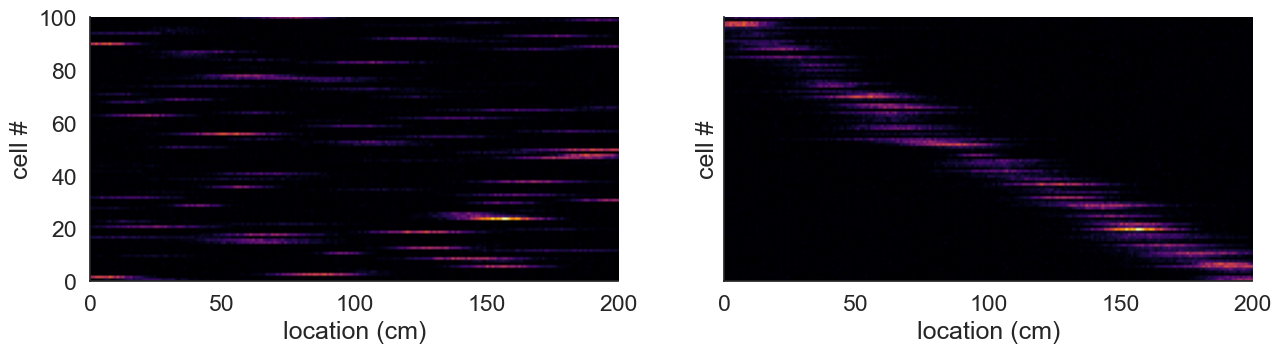

--------------------------------------------------
bin space = 3.0
--------------------------------------------------


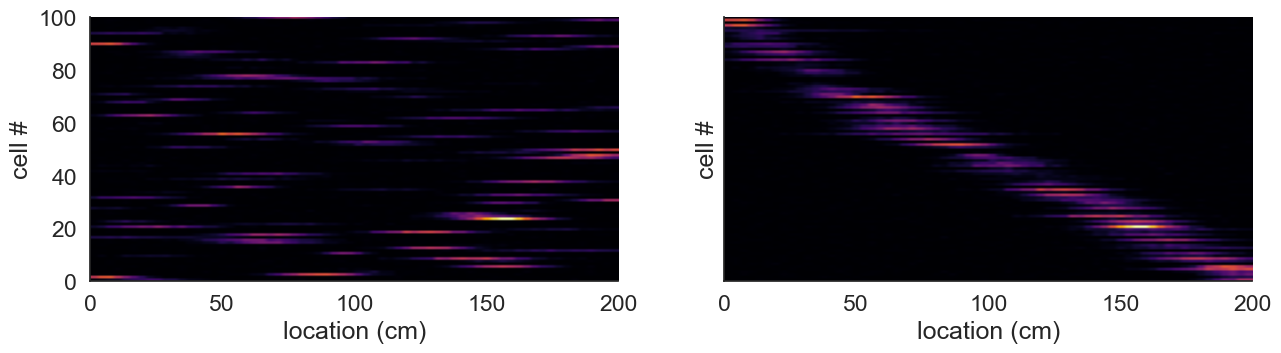

--------------------------------------------------
bin space = 5.0
--------------------------------------------------


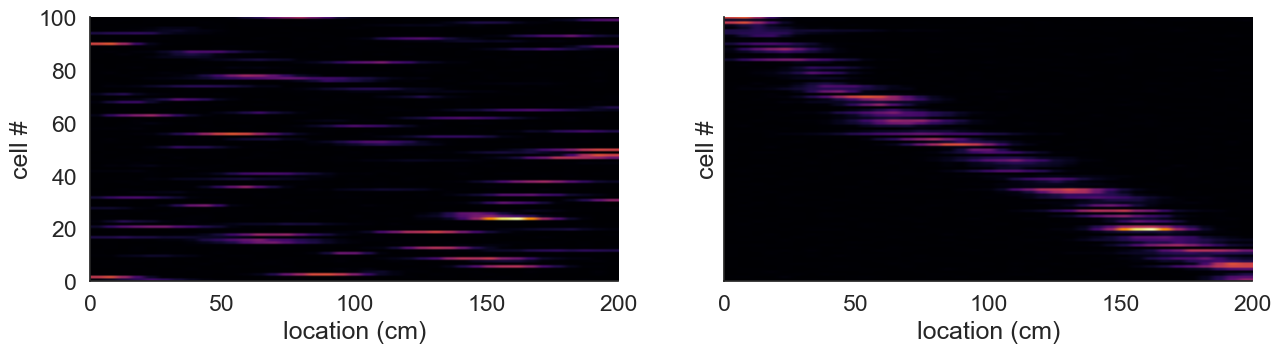

--------------------------------------------------
bin space = 10.0
--------------------------------------------------


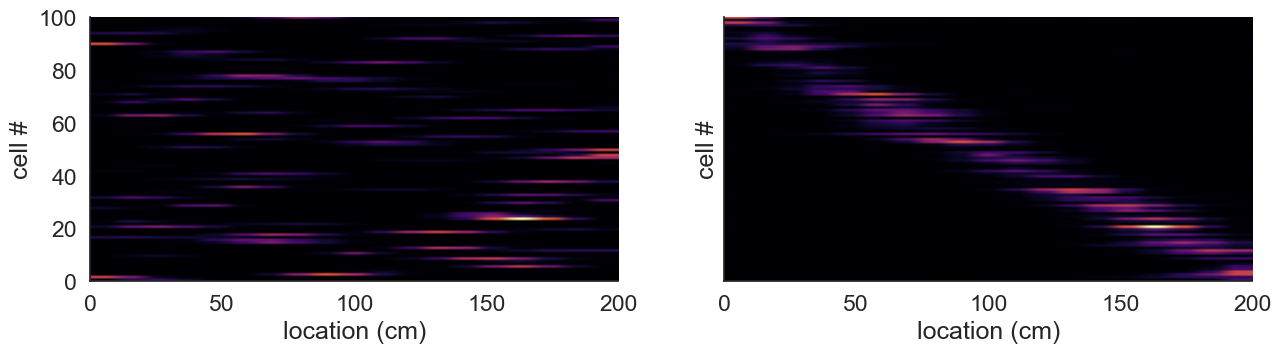

--------------------------------------------------
bin space = 25.0
--------------------------------------------------


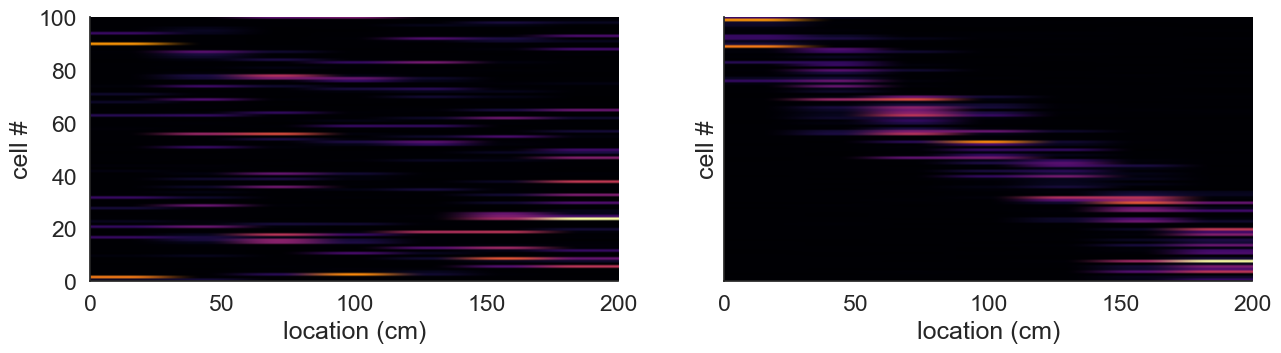

In [6]:
def Get_Firing_Rate_Maps(bin_width,spike_positions,fps,n_cells):
    space_bins = np.arange(0., 200., bin_width)

    # we compute histograms for eaxh cell
    spikes_hist= [np.histogram(s, space_bins)[0] for s in spike_positions]
    
    # put them together into a matrix of floating point numbers (for plotting)
    spikes_hist = np.vstack(spikes_hist).astype(np.float64)
    
    # we also need an "occupancy histogram" in order to normalize the firing rates maps 
    occupancy = np.histogram(x, space_bins)[0] /  fps
    
    firing_rate_maps = spikes_hist / occupancy 
    return firing_rate_maps,occupancy

def plot_mouse_data(firing_rate_maps,n_cells):
    #plt.figure(figsize=(15,5))
    fig,axs = plt.subplots(ncols=2,figsize=(15,5),sharey=True)
    axs[0].imshow(firing_rate_maps, cmap='inferno', extent = [0, 200, 0, n_cells])
    axs[0].set_xlabel('location (cm)')
    axs[0].set_ylabel('cell #')
    #axs[0].colorbar()
    
    #plt.figure(figsize=(15,5))
    peak_locations = firing_rate_maps.argmax(axis=1)
    ix = np.argsort(peak_locations)
    axs[1].imshow(firing_rate_maps[ix,:], cmap='inferno', extent = [0, 200, 0, n_cells])
    axs[1].set_xlabel('location (cm)')
    axs[1].set_ylabel('cell #')
    #axs[1].colorbar()
    
    plt.show()
    plt.close()

bin_widths = np.array([.5,1.,3.,5.,10.,25.])
for bin_width in bin_widths:
    print(50*f'-'+f'\n'+f'bin space = {bin_width}\n'+50*f'-')
    firing_rate_maps,occupancy = Get_Firing_Rate_Maps(bin_width,spike_positions=spike_positions,fps=fps,n_cells=n_cells)
    plot_mouse_data(firing_rate_maps,n_cells=n_cells)

B - In the spike train simulations, we add some "baseline" noise, not place-related to the firing. Which variable determines the noise level? Try to experiment with that variable and see what happens to the firing rate maps. What is the best approach to firing rate maps when the noise is high.

100%|██████████| 100/100 [00:47<00:00,  2.09it/s]


--------------------------------------------------
noise firing rate = 0.15 
 bin space = 0.5
--------------------------------------------------


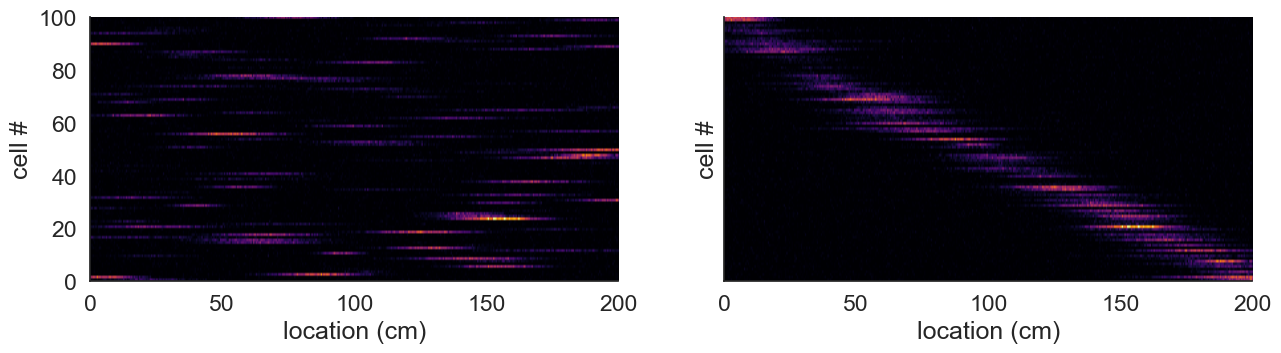

--------------------------------------------------
noise firing rate = 0.15 
 bin space = 1.0
--------------------------------------------------


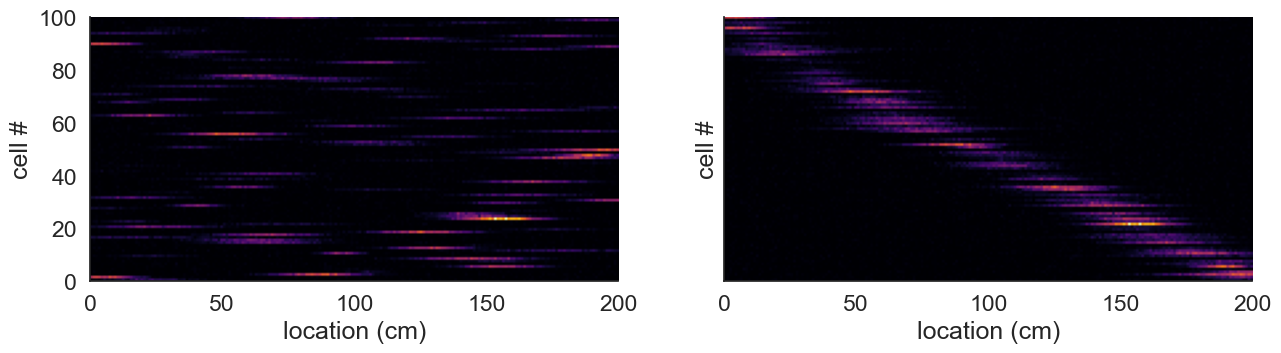

--------------------------------------------------
noise firing rate = 0.15 
 bin space = 3.0
--------------------------------------------------


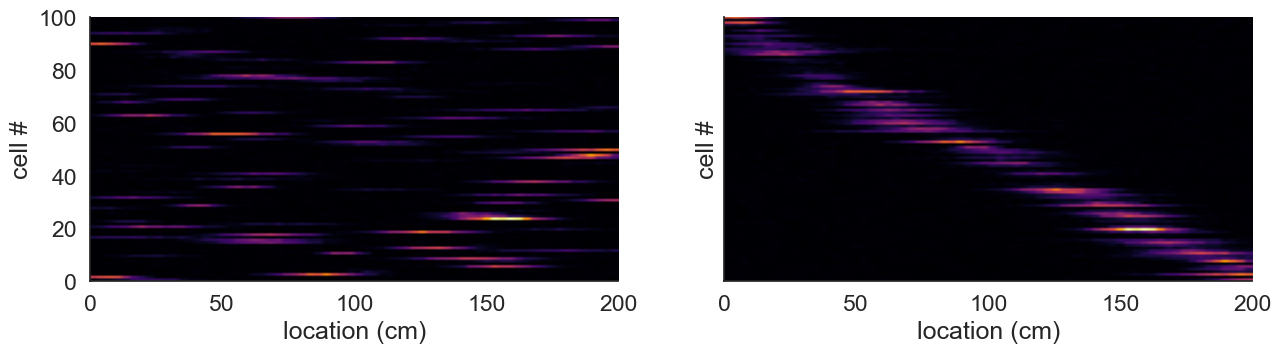

--------------------------------------------------
noise firing rate = 0.15 
 bin space = 5.0
--------------------------------------------------


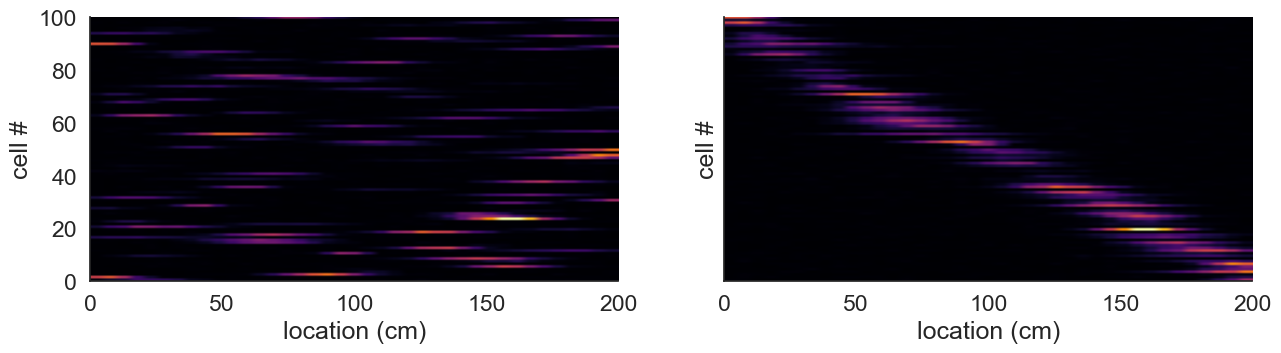

--------------------------------------------------
noise firing rate = 0.15 
 bin space = 10.0
--------------------------------------------------


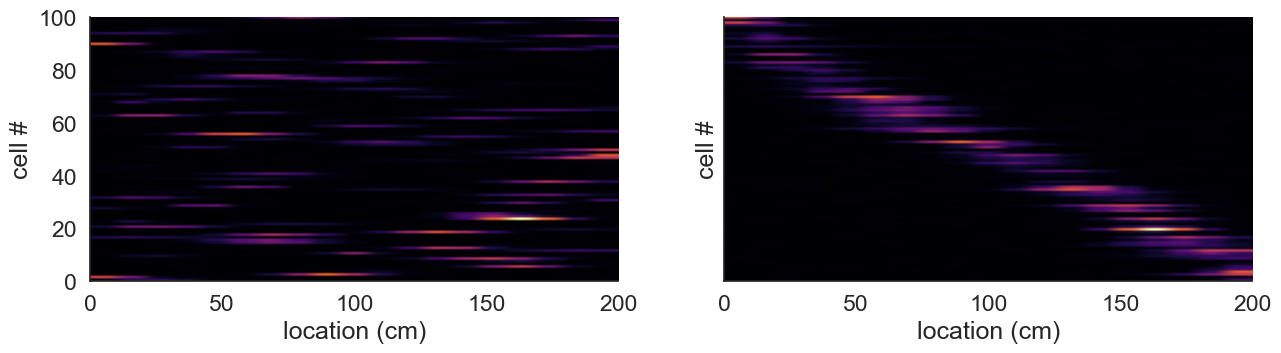

--------------------------------------------------
noise firing rate = 0.15 
 bin space = 25.0
--------------------------------------------------


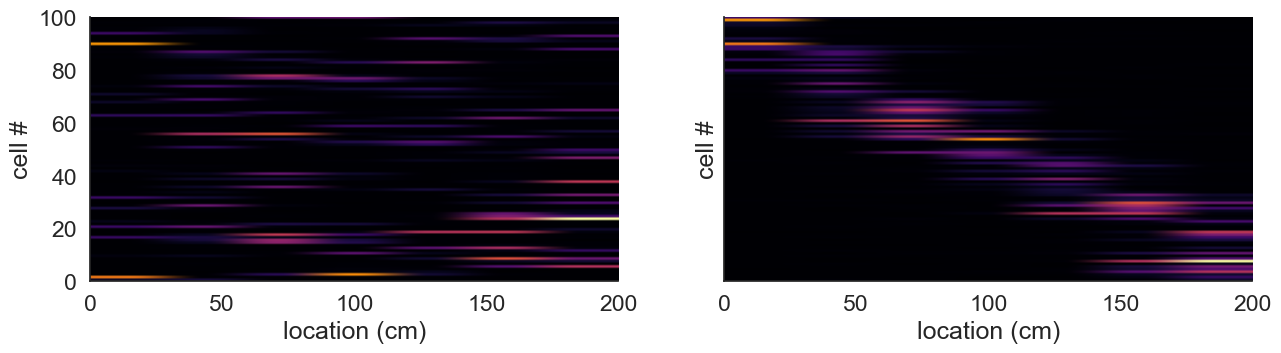

100%|██████████| 100/100 [00:47<00:00,  2.10it/s]


--------------------------------------------------
noise firing rate = 0.25 
 bin space = 0.5
--------------------------------------------------


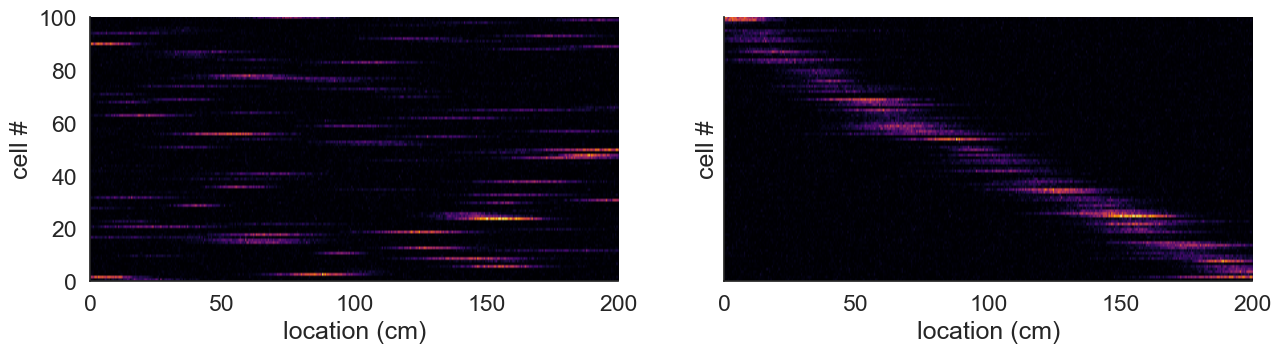

--------------------------------------------------
noise firing rate = 0.25 
 bin space = 1.0
--------------------------------------------------


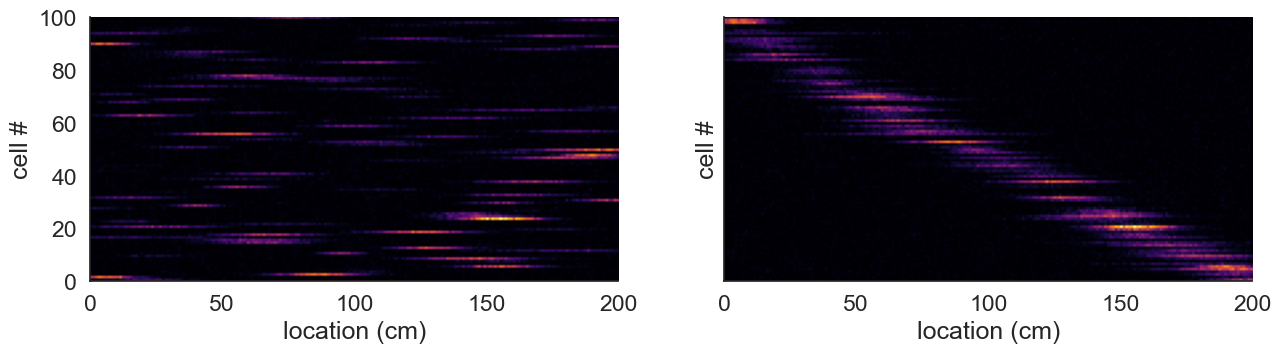

--------------------------------------------------
noise firing rate = 0.25 
 bin space = 3.0
--------------------------------------------------


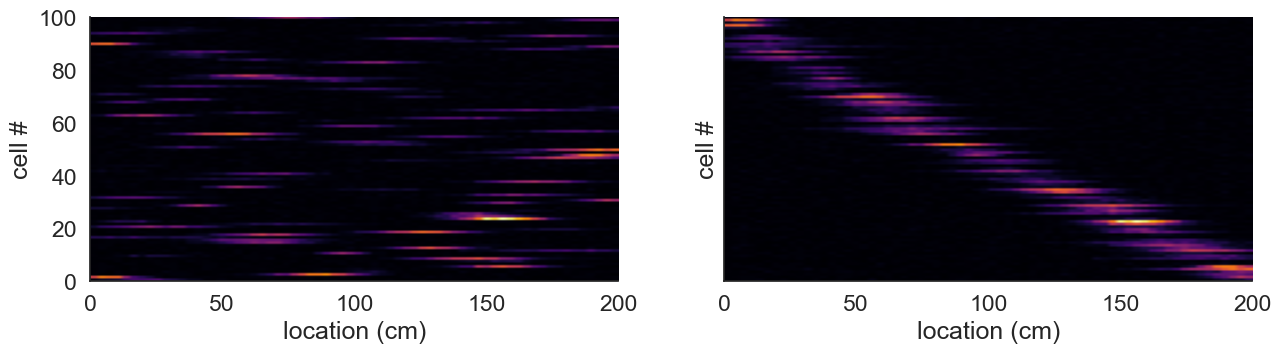

--------------------------------------------------
noise firing rate = 0.25 
 bin space = 5.0
--------------------------------------------------


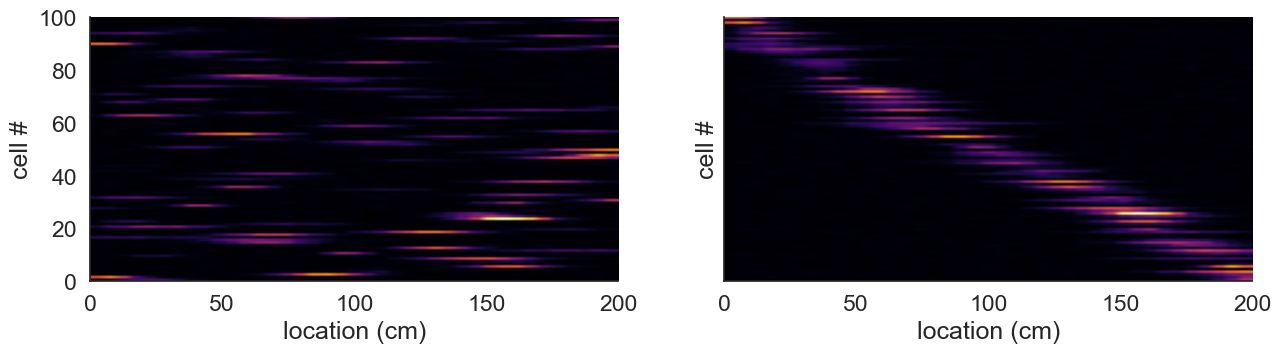

--------------------------------------------------
noise firing rate = 0.25 
 bin space = 10.0
--------------------------------------------------


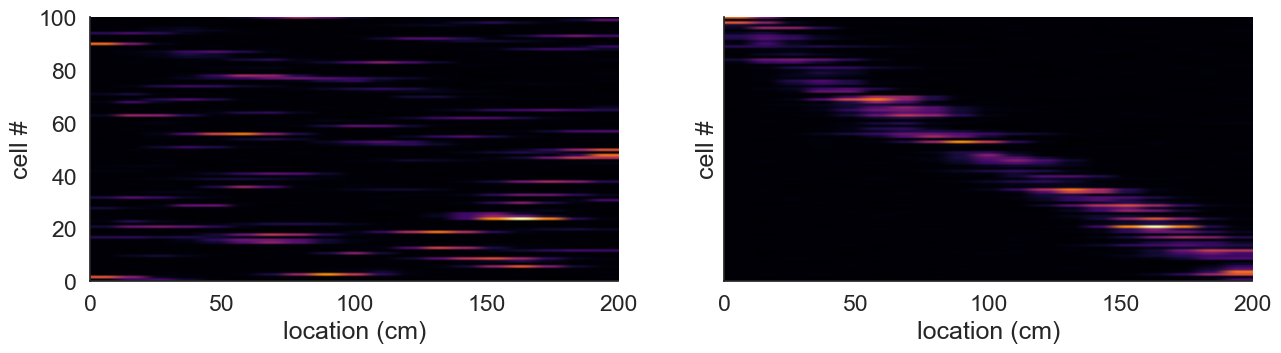

--------------------------------------------------
noise firing rate = 0.25 
 bin space = 25.0
--------------------------------------------------


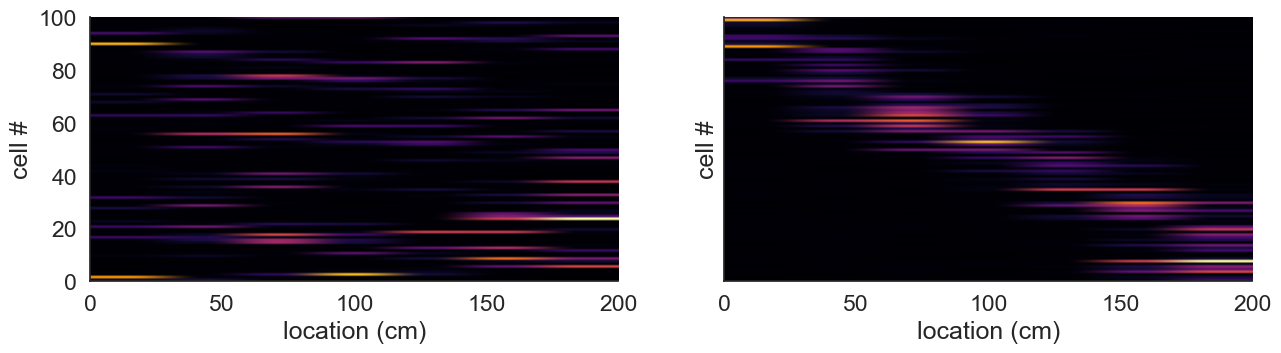

100%|██████████| 100/100 [00:49<00:00,  2.02it/s]


--------------------------------------------------
noise firing rate = 0.5 
 bin space = 0.5
--------------------------------------------------


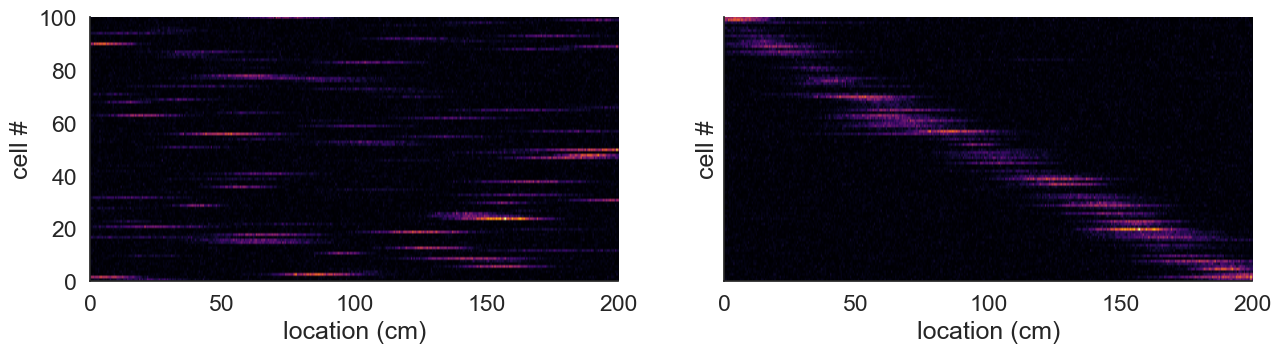

--------------------------------------------------
noise firing rate = 0.5 
 bin space = 1.0
--------------------------------------------------


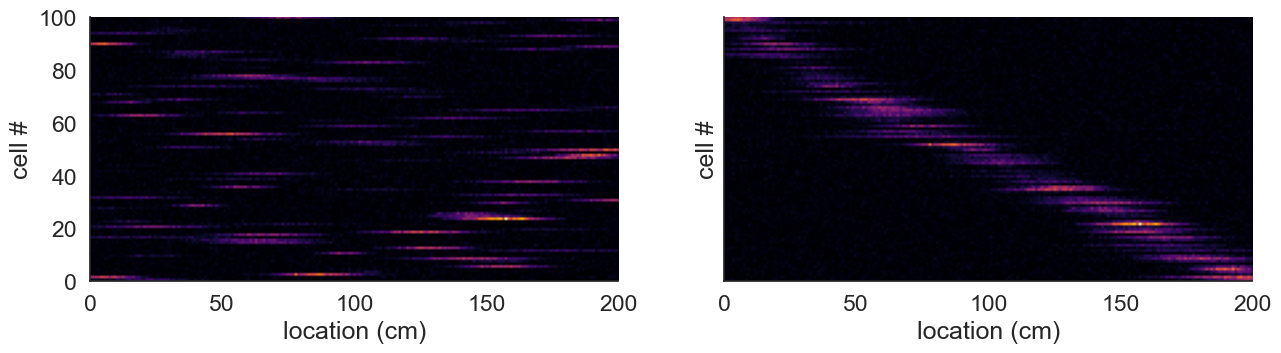

--------------------------------------------------
noise firing rate = 0.5 
 bin space = 3.0
--------------------------------------------------


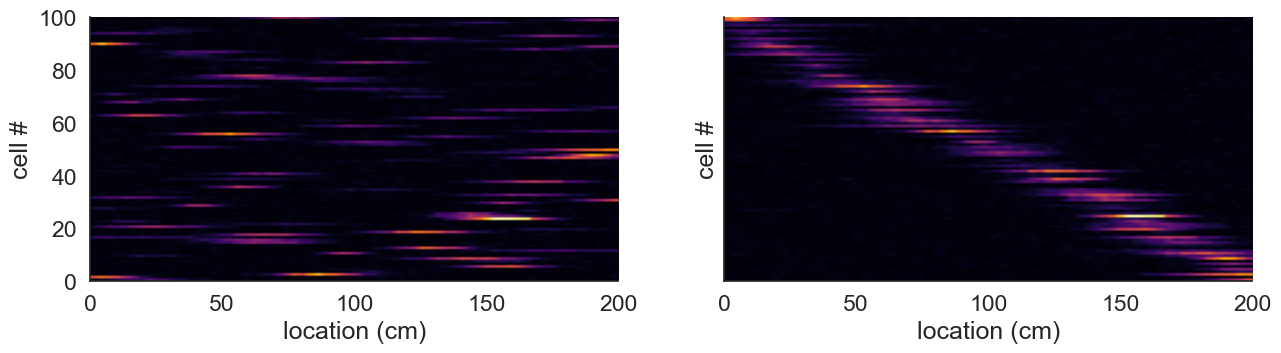

--------------------------------------------------
noise firing rate = 0.5 
 bin space = 5.0
--------------------------------------------------


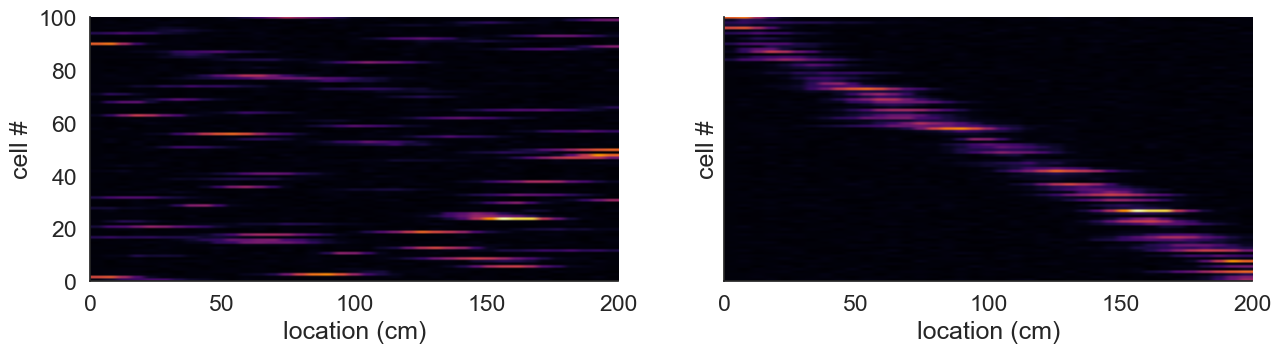

--------------------------------------------------
noise firing rate = 0.5 
 bin space = 10.0
--------------------------------------------------


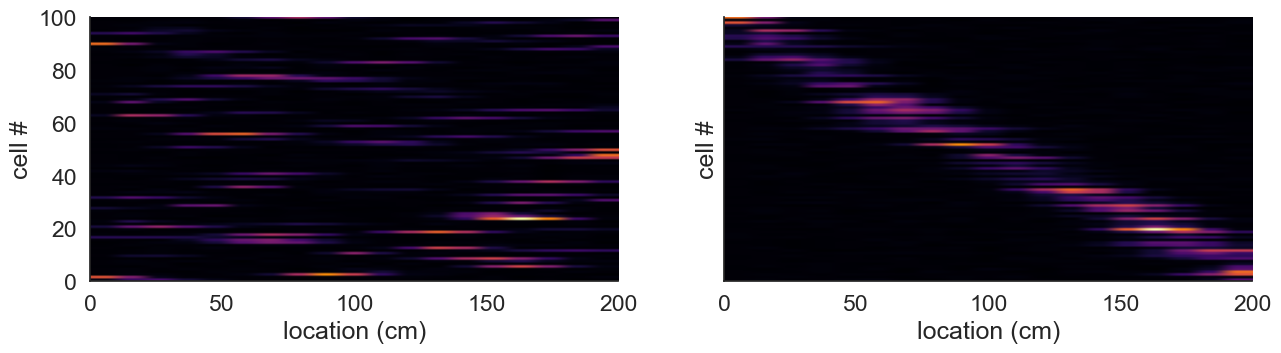

--------------------------------------------------
noise firing rate = 0.5 
 bin space = 25.0
--------------------------------------------------


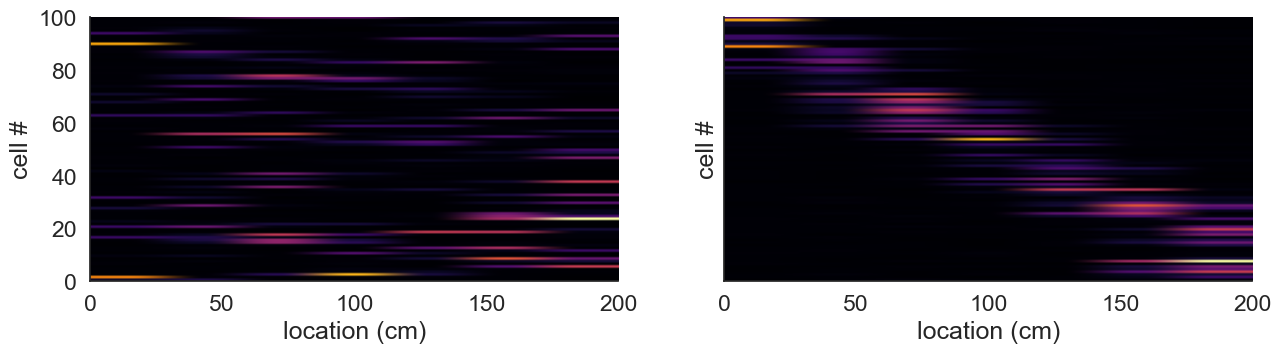

100%|██████████| 100/100 [00:49<00:00,  2.02it/s]


--------------------------------------------------
noise firing rate = 0.8 
 bin space = 0.5
--------------------------------------------------


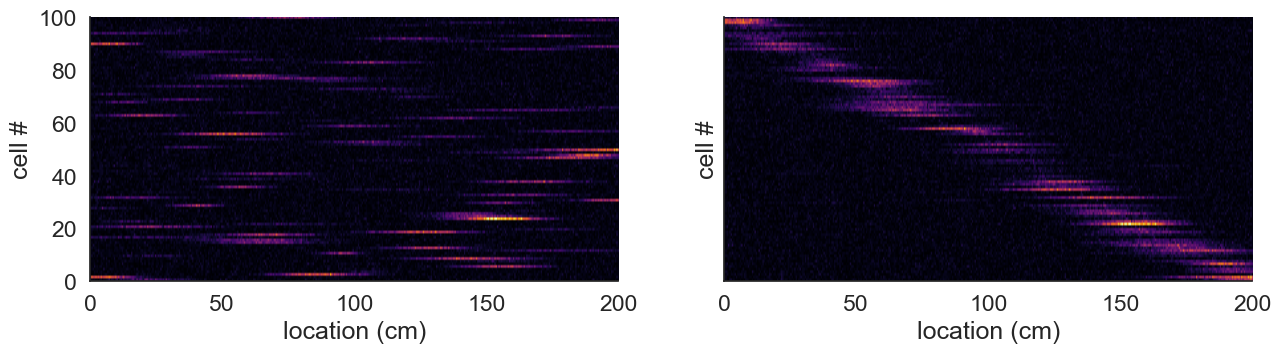

--------------------------------------------------
noise firing rate = 0.8 
 bin space = 1.0
--------------------------------------------------


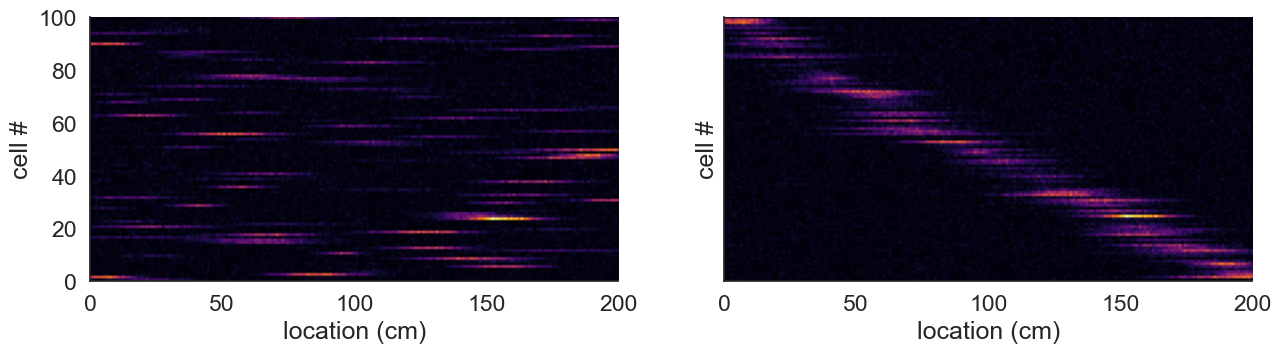

--------------------------------------------------
noise firing rate = 0.8 
 bin space = 3.0
--------------------------------------------------


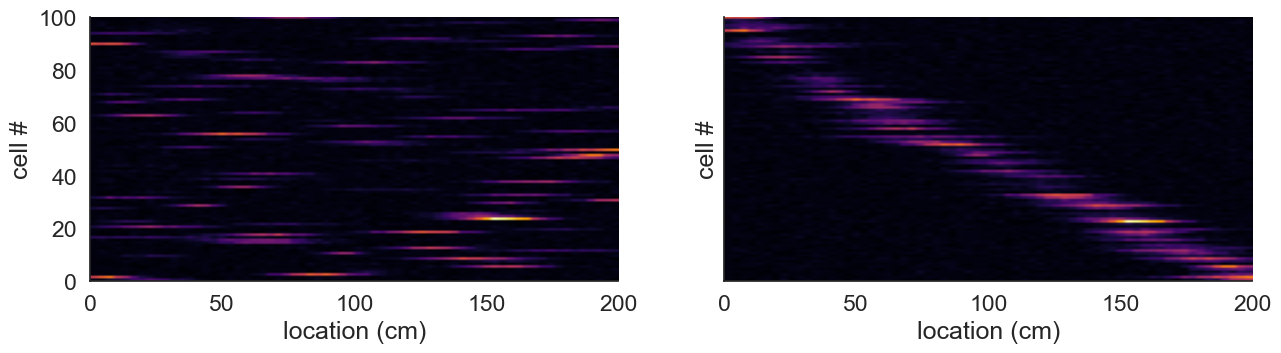

--------------------------------------------------
noise firing rate = 0.8 
 bin space = 5.0
--------------------------------------------------


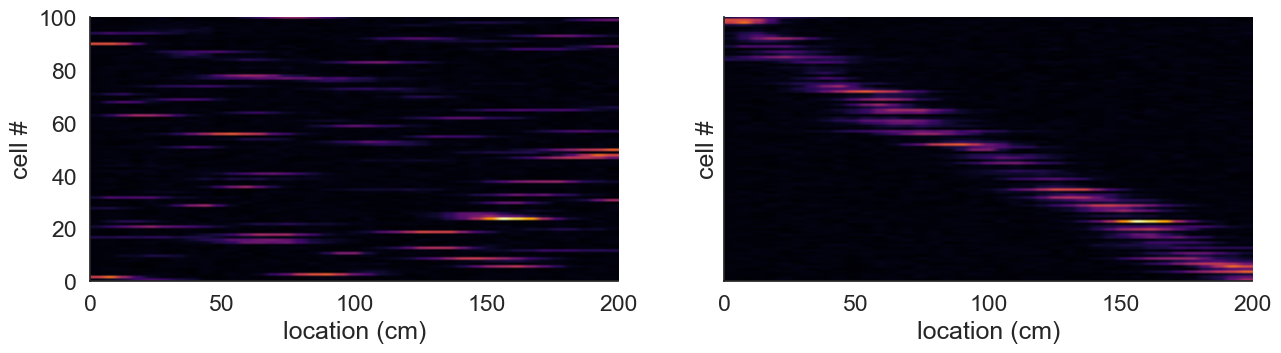

--------------------------------------------------
noise firing rate = 0.8 
 bin space = 10.0
--------------------------------------------------


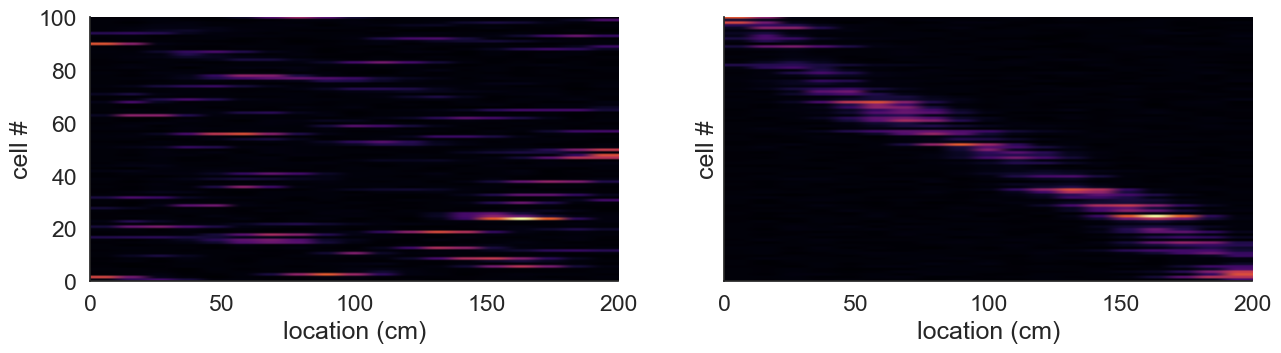

--------------------------------------------------
noise firing rate = 0.8 
 bin space = 25.0
--------------------------------------------------


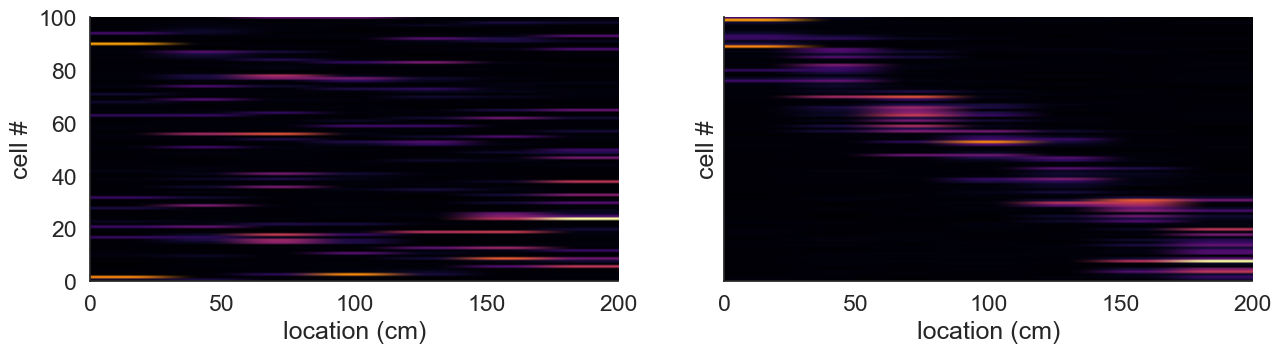

In [7]:
#B
#Change noise firing rate in Sample_data, see what changes
noise_rates = np.array([.15,.25,.5,.8])
bin_widths = np.array([.5,1.,3.,5.,10.,25.])

for noise_rate in noise_rates:
    spike_positions = Sample_data(x,t,n_cells,true_firing_rate_maps,noise_firing_rate=noise_rate)
    for bin_width in bin_widths:
        print(50*f'-'+f'\n'+f'noise firing rate = {noise_rate} \n bin space = {bin_width}\n'+50*f'-')
        firing_rate_maps,occupancy = Get_Firing_Rate_Maps(bin_width,spike_positions=spike_positions,fps=fps,n_cells=n_cells)
        plot_mouse_data(firing_rate_maps,n_cells=n_cells)

C - We could use other approaches to firing rate maps: for example make the binning very small (down to 1 cm, which is the resolution of our "video" data, and then applying a gaussian smoother. Scipy has a Gaussian smoother at `scipy.stats.gaussian_kde`. Read the documentation for that function and apply it to the data to define the smoothed firing rate maps. Again, change the noise levels and see how the smoother changes. 

In [8]:
#C
def Sample_Data_Smoothed(x,t,n_cells,true_firing_rate_maps,sampling_rate=10000.,noise_firing_rate=0.1):
    #sampling_rate = 10000.
    t_sampling = np.arange(0, t[-1], 1. / sampling_rate)
    x_sampling = np.floor(np.interp(t_sampling, t, x))
    #noise_firing_rate = 0.1 # the baseline noise firing rate
    spikes = []
    
    for i in tqdm(range(n_cells)):
        inst_rate = true_firing_rate_maps[i,x_sampling.astype(np.int32)] + noise_firing_rate
        spikes_loc = np.random.poisson(inst_rate/sampling_rate)
        sp = np.argwhere(spikes_loc)
        t_sp = t_sampling[sp]
        spikes.append(t_sp)
    
    spike_positions = [np.interp(s, t, x) for s in spikes]
    for i in tqdm(range(n_cells)):
        spike_positions[i] = scipy.stats.gaussian_kde(spike_positions[i])

    return spike_positions

noise_rates = np.array([.1,.15,.25,.5,.8])
bin_widths = np.array([.5,1.,3.,5.,10.,25.])

for noise_rate in noise_rates:
    #spike_positions = Sample_Data_Smoothed(x,t,n_cells,true_firing_rate_maps,noise_firing_rate=noise_rate)
    for bin_width in bin_widths:
        print(50*f'-'+f'\n'+f'noise firing rate = {noise_rate} \n bin space = {bin_width}\n'+50*f'-')
        #plot_mouse_data(bin_width,spike_positions=spike_positions,fps=fps,n_cells=n_cells)

--------------------------------------------------
noise firing rate = 0.1 
 bin space = 0.5
--------------------------------------------------
--------------------------------------------------
noise firing rate = 0.1 
 bin space = 1.0
--------------------------------------------------
--------------------------------------------------
noise firing rate = 0.1 
 bin space = 3.0
--------------------------------------------------
--------------------------------------------------
noise firing rate = 0.1 
 bin space = 5.0
--------------------------------------------------
--------------------------------------------------
noise firing rate = 0.1 
 bin space = 10.0
--------------------------------------------------
--------------------------------------------------
noise firing rate = 0.1 
 bin space = 25.0
--------------------------------------------------
--------------------------------------------------
noise firing rate = 0.15 
 bin space = 0.5
----------------------------------------

In [9]:
def plot_mouse_data_smoothed(bin_width,spike_positions,fps,n_cells):
    space_bins = np.arange(0., 200., bin_width)

    # we compute histograms for eaxh cell
    spikes_hist= [np.histogram(s, space_bins)[0] for s in spike_positions]
    
    # put them together into a matrix of floating point numbers (for plotting)
    spikes_hist = np.vstack(spikes_hist).astype(np.float64)
    
    # we also need an "occupancy histogram" in order to normalize the firing rates maps 
    occupancy = np.histogram(x, space_bins)[0] /  fps
    
    firing_rate_maps = spikes_hist / occupancy 
    for i in tqdm(range(n_cells)):
        firing_rate_maps[i] = scipy.stats.gaussian_kde(firing_rate_maps[i])
    
    #plt.figure(figsize=(15,5))
    fig,axs = plt.subplots(ncols=2,figsize=(15,5),sharey=True)
    axs[0].imshow(firing_rate_maps, cmap='inferno', extent = [0, 200, 0, n_cells])
    axs[0].set_xlabel('location (cm)')
    axs[0].set_ylabel('cell #')
    #axs[0].colorbar()
    
    #plt.figure(figsize=(15,5))
    peak_locations = firing_rate_maps.argmax(axis=1)
    ix = np.argsort(peak_locations)
    axs[1].imshow(firing_rate_maps[ix,:], cmap='inferno', extent = [0, 200, 0, n_cells])
    axs[1].set_xlabel('location (cm)')
    axs[1].set_ylabel('cell #')
    #axs[1].colorbar()
    
    plt.show()
    plt.close()

noise_rates = np.array([.1,.15,.25,.5,.8])
bin_widths = np.array([.5,1.,3.,5.,10.,25.])

for noise_rate in noise_rates:
    #spike_positions = Sample_data(x,t,n_cells,true_firing_rate_maps,noise_firing_rate=noise_rate)
    for bin_width in bin_widths:
        print(50*f'-'+f'\n'+f'noise firing rate = {noise_rate} \n bin space = {bin_width}\n'+50*f'-')
        #plot_mouse_data_smoothed(bin_width,spike_positions=spike_positions,fps=fps,n_cells=n_cells)

--------------------------------------------------
noise firing rate = 0.1 
 bin space = 0.5
--------------------------------------------------
--------------------------------------------------
noise firing rate = 0.1 
 bin space = 1.0
--------------------------------------------------
--------------------------------------------------
noise firing rate = 0.1 
 bin space = 3.0
--------------------------------------------------
--------------------------------------------------
noise firing rate = 0.1 
 bin space = 5.0
--------------------------------------------------
--------------------------------------------------
noise firing rate = 0.1 
 bin space = 10.0
--------------------------------------------------
--------------------------------------------------
noise firing rate = 0.1 
 bin space = 25.0
--------------------------------------------------
--------------------------------------------------
noise firing rate = 0.15 
 bin space = 0.5
----------------------------------------

D - When analyzing place fields, two important quantities are the place field center and the place field width. The place field center may be defined in many ways, but one is to compute the "center of mass" of the spikes according to the equation 

$$ c_{pf} = \frac{1}{N_{spikes}} \sum_{i} L_i $$ 

where the sum on $i$ runs on all spikes emitted by a cell and $L_i$ is the location at which the i-th spike was emitted. Calculate this for each cell. Compare with the "true" place field centers from the simulations (which variables are we talking about?) 

100%|██████████| 100/100 [00:00<00:00, 83768.80it/s]


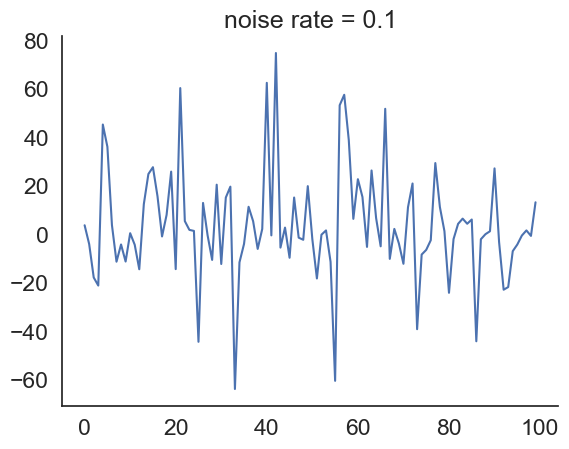

100%|██████████| 100/100 [00:00<00:00, 79906.73it/s]


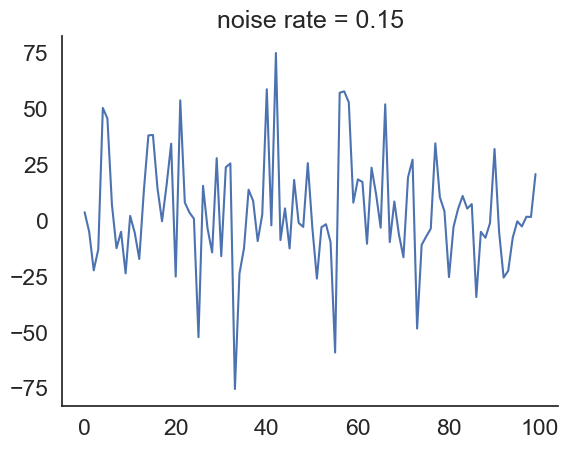

100%|██████████| 100/100 [00:00<00:00, 60743.00it/s]


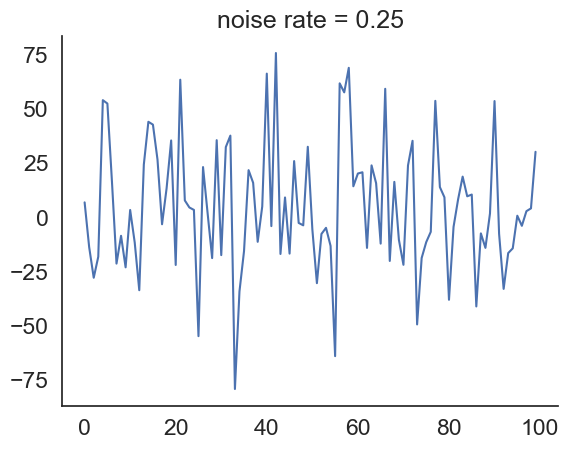

100%|██████████| 100/100 [00:00<00:00, 84545.54it/s]


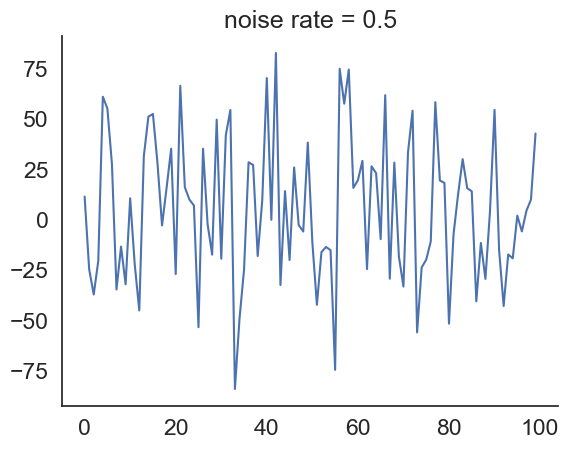

100%|██████████| 100/100 [00:00<00:00, 54913.64it/s]


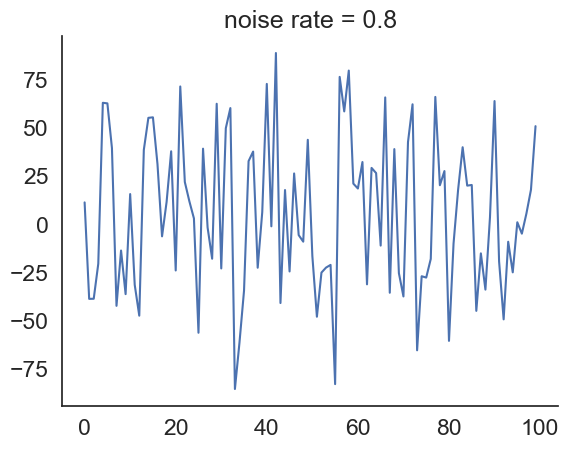

In [10]:
#D
#parameters for sampled data to be used

def Calculate_CoM(spike_positions,n_cells):
    if len(spike_positions) != n_cells: raise("Number of measured cells doesn't equal expected number of cells")

    c_pf = []
    for i in tqdm(range(n_cells)):
        c_pf.append(np.sum(spike_positions[i])/len(spike_positions[i]))
    return np.array(c_pf)

#c_pf = Calculate_CoM(spike_positions,100)

noise_rates = np.array([.1,.15,.25,.5,.8])

for noise_rate in noise_rates:
    spike_positions = Sample_data(x,t,n_cells,true_firing_rate_maps,noise_firing_rate=noise_rate)
    c_pf = Calculate_CoM(spike_positions,n_cells)
    plt.plot(c_pf-pf_centers)
    plt.title(f'noise rate = {noise_rate}')
    plt.show()
    plt.close()

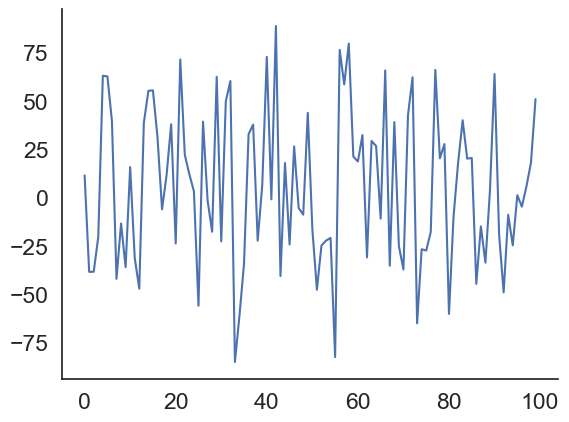

In [11]:
plt.plot(c_pf-pf_centers)

## Exercise 2 - mutual information
---
A - Implement the mutual information formula discussed in the lesson, and apply it to the place cell data we simulated.

In [12]:
#A
#Set parameters of simulating data, and simulate data

def Spatial_Information(firing_rate_maps,occupancy):
    space_bins = np.arange(0., 200., bin_width)

    # we compute histograms for eaxh cell
    spikes_hist= [np.histogram(s, space_bins)[0] for s in spike_positions]
    
    # put them together into a matrix of floating point numbers (for plotting)
    spikes_hist = np.vstack(spikes_hist).astype(np.float64)
    
    # we also need an "occupancy histogram" in order to normalize the firing rates maps 
    occupancy = np.histogram(x, space_bins)[0] /  fps
    
    firing_rate_maps = spikes_hist / occupancy
    
    information = []
    for i in tqdm(range(n_cells)):
        information.append(np.sum(firing_rate_maps[i]*np.log2((firing_rate_maps[i]+1.e-15)*occupancy/np.mean(firing_rate_maps[i]))))
    return np.array(information)
    
Spatial_Information(firing_rate_maps,occupancy)   

100%|██████████| 100/100 [00:00<00:00, 40462.13it/s]


array([108.77402332,  41.52814057,  59.42093264,  48.38002426,
        41.85394009,  47.05061888,  69.9524348 ,  74.02805241,
        82.06046961,  57.67191588, 167.43284747,  39.23461792,
        64.53786295,  75.75227335,  51.72197134,  49.20416779,
        52.4545173 , 103.46599255,  39.81774318,  45.38378271,
        40.61858156,  39.3767287 , 110.73701296, 126.35896742,
        61.78500699,  42.07980243,  75.60148149,  68.05809814,
        51.42558531,  50.99974951,  53.52796344,  65.03418793,
        50.17288513,  39.77765463,  39.93995166,  87.27597899,
        58.43754951,  79.26045622,  91.86363691,  44.6403719 ,
        40.16705055,  80.79091645,  38.08746964,  51.72186957,
       166.8751378 ,  78.17273297,  53.18647898,  80.98000048,
        63.12330203,  66.17380691,  62.83173224,  59.17456264,
        41.71595861,  83.49457715,  49.24923509,  41.68327006,
        41.51662315,  41.28051613,  42.56531315,  85.4475368 ,
        44.23750048,  64.34489421, 107.82050588,  40.86

B - Adapt the simulation so that you can systematically vary 1) Peak firing rate, 2) place cell size 3) baseline noise. 
Study how mutual information vary with these parameters. Use both definition of mutual information above, and discuss the differences between them. Make some plots to show how the dependency goes.

In [13]:
#B

track_length = 200. # the length of our linear track (eg in centimeter)
average_firing_rate = 5 # the peak firing rate, averaged across the population 
cell_size = 10 #The size of the place cells
n_cells = 100 # how many cells we are recording
seed = 42

n_runs = 20 
av_running_speed = 10 # the average running speed (in cm/s)
fps = 30 # the number of "video frames" per second 
av_wait_time = 15 # the average waiting time



def Get_Information(average_firing_rate = 5,cell_size = 10,n_cells = 100,track_length = 200,n_runs = 20,av_running_speed = 10,av_wait_time = 15,fps = 30,noise_firing_rate = .1,bin_width=5,seed=42):
    true_firing_rate_maps,pf_centers,pf_size,pf_rate,bins =  True_Place_Cells(average_firing_rate = average_firing_rate,cell_size = cell_size,n_cells = n_cells,track_length = track_length,seed=seed)
    x,t = mouse_position(n_runs = n_runs,av_running_speed = av_running_speed,av_wait_time = av_wait_time,fps = fps,bins=bins,seed=seed)
    spike_positions = Sample_data(x,t,n_cells,true_firing_rate_maps,noise_firing_rate = noise_firing_rate)
    firing_rate_maps,occupancy = Get_Firing_Rate_Maps(bin_width,spike_positions,fps,n_cells)
    return Spatial_Information(firing_rate_maps = firing_rate_maps,occupancy = occupancy)


In [14]:
Info = Get_Information()

100%|██████████| 100/100 [00:00<00:00, 61141.46it/s]


72.22607003895091 35.97493257241105


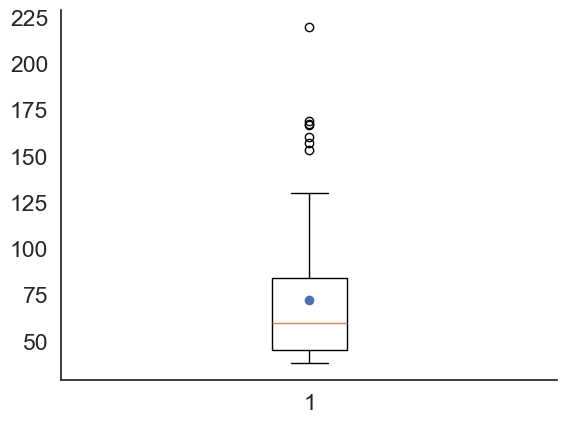

In [15]:
print(np.mean(Info),np.std(Info))

plt.boxplot(Info)
plt.plot(1,np.mean(Info),'o')
plt.show()


In [16]:

Peak_Firing_Rates = np.array([4,5,6])
Place_Cell_Sizes = np.array([9,10,11])
Baseline_Firing_Noise = np.array([.1,.15,.25,.5,.8])

Info_tot = []
for p_fr in Peak_Firing_Rates:
    Info_sn = []
    for pl_size in Place_Cell_Sizes:
        Info_n = []
        for fr_noise in Baseline_Firing_Noise:
            Info_n.append(Get_Information(average_firing_rate = p_fr,cell_size = pl_size,noise_firing_rate = fr_noise))
        Info_sn.append(np.array(Info_n))
    Info_tot.append(np.array(Info_sn))
Info_tot = np.array(Info_tot)

            

100%|██████████| 100/100 [00:00<00:00, 64867.06it/s]


In [17]:
print('Done')

Done


In [18]:
print(Info_tot)

[[[[108.77402332  41.52814057  59.42093264 ... 169.18899234
    153.12764796  60.03388693]
   [108.77402332  41.52814057  59.42093264 ... 169.18899234
    153.12764796  60.03388693]
   [108.77402332  41.52814057  59.42093264 ... 169.18899234
    153.12764796  60.03388693]
   [108.77402332  41.52814057  59.42093264 ... 169.18899234
    153.12764796  60.03388693]
   [108.77402332  41.52814057  59.42093264 ... 169.18899234
    153.12764796  60.03388693]]

  [[108.77402332  41.52814057  59.42093264 ... 169.18899234
    153.12764796  60.03388693]
   [108.77402332  41.52814057  59.42093264 ... 169.18899234
    153.12764796  60.03388693]
   [108.77402332  41.52814057  59.42093264 ... 169.18899234
    153.12764796  60.03388693]
   [108.77402332  41.52814057  59.42093264 ... 169.18899234
    153.12764796  60.03388693]
   [108.77402332  41.52814057  59.42093264 ... 169.18899234
    153.12764796  60.03388693]]

  [[108.77402332  41.52814057  59.42093264 ... 169.18899234
    153.12764796  60.03388

In [28]:
print(Info_tot.shape)

def plot_Box_n_Heat(i,j):
    plt.boxplot(Info_tot[i,j].T)
    plt.plot(np.arange(1,1+Info_tot.shape[2]),np.mean(Info_tot[i,j],axis=1),'o')
    plt.show()
    plt.close()
    
    plt.imshow(Info_tot[i,j])
    plt.show()
    plt.close()

interact(plot_Box_n_Heat, i = widgets.IntSlider(min=0, max=2, value=0),j = widgets.IntSlider(min=0, max=2, value=0))

(3, 3, 5, 100)


interactive(children=(IntSlider(value=0, description='i', max=2), IntSlider(value=0, description='j', max=2), …

<function __main__.plot_Box_n_Heat(i, j)>

## Exercise 3 - working with real data
---
Load the data from `linear_track_data.pickle`. It contains neural recordings from a mouse running on a linear track.
- `x` contains the position of the animal
- `t` contains the corresponding times, in seconds
- `spikes` contains a list of lists. Each list contains the timestamps of the spikes emitted by a neuron.

In [20]:
download_data('https://surfdrive.surf.nl/s/z7mMiznEWOT0Iak')

In [21]:
with open('data/linear_track_data.pickle', 'rb') as handle:
    mouse_data = pickle.load(handle)

print(mouse_data.keys())
x = mouse_data['x']
t = mouse_data['t']
sp = mouse_data['spikes']

n_cells = len(sp)
fps = 1/(t[1]-t[0])

dict_keys(['x', 't', 'spikes'])


C:\Users\KHofman\AppData\Local\Temp\ipykernel_21352\756425646.py:2: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  mouse_data = pickle.load(handle)


A - Visualiaze the position a s a function of time. Plot the spike of a selected cell in space.

In [22]:
#A
def plot_spike_locations(i):
    plt.plot(t,x,label='Position of the mouse')
    plt.scatter(sp[i],np.interp(sp[i],t,x),c='r',label=f'spikes cell {i}')
    plt.legend(loc=1)

interact(plot_spike_locations, i = widgets.IntSlider(min=0,max=(n_cells-1), value=10))

interactive(children=(IntSlider(value=10, description='i', max=71), Output()), _dom_classes=('widget-interact'…

<function __main__.plot_spike_locations(i)>

B - Calculate the firing rate maps for all the cells, and plot them sorted by increasing peak positon.

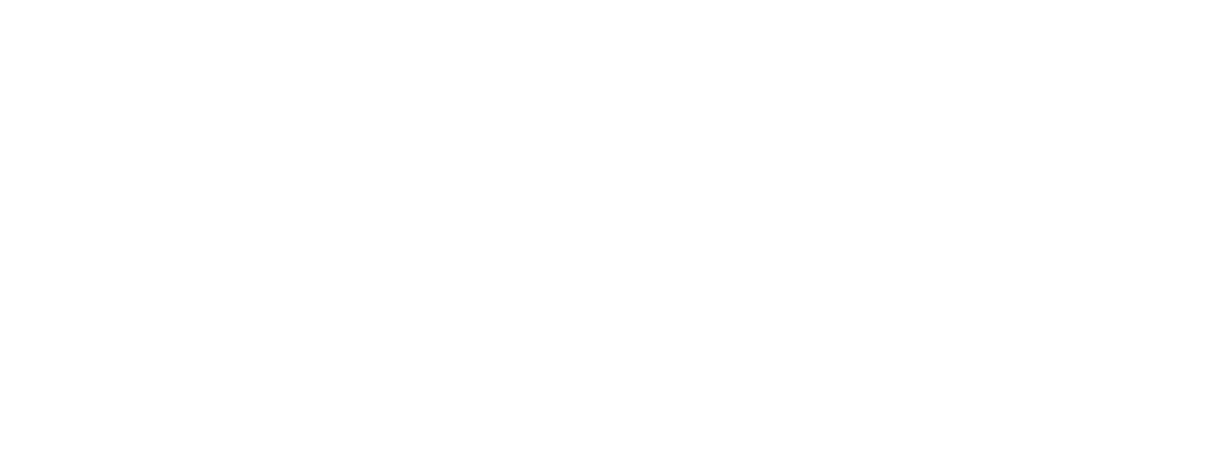

In [23]:
#B
spike_positions = [np.interp(s, t, x) for s in sp]
bin_width = 10
tracklength = round(max(x))

def Get_Firing_Rate_Maps_2(bin_width,spike_positions,fps,n_cells,tracklength):
    space_bins = np.arange(0.,tracklength, bin_width)

    # we compute histograms for eaxh cell
    spikes_hist= [np.histogram(s, space_bins)[0] for s in spike_positions]
    
    # put them together into a matrix of floating point numbers (for plotting)
    spikes_hist = np.vstack(spikes_hist).astype(np.float64)
    
    # we also need an "occupancy histogram" in order to normalize the firing rates maps 
    occupancy = np.histogram(x, space_bins)[0] /  fps
    
    firing_rate_maps = spikes_hist / occupancy 
    return firing_rate_maps,occupancy

def plot_mouse_data_2(firing_rate_maps,n_cells,tracklength):
    #plt.figure(figsize=(15,5))
    fig,axs = plt.subplots(ncols=2,figsize=(15,5),sharey=True)
    axs[0].imshow(firing_rate_maps, cmap='inferno', extent = [0, tracklength, 0, n_cells])
    axs[0].set_xlabel('location (cm)')
    axs[0].set_ylabel('cell #')
    #axs[0].colorbar()
    
    #plt.figure(figsize=(15,5))
    peak_locations = firing_rate_maps.argmax(axis=1)
    ix = np.argsort(peak_locations)
    axs[1].imshow(firing_rate_maps[ix,:], cmap='inferno', extent = [0, tracklength, 0, n_cells])
    axs[1].set_xlabel('location (cm)')
    axs[1].set_ylabel('cell #')
    #axs[1].colorbar()
    
    plt.show()
    plt.close()

firing_rate_maps,occupancy = Get_Firing_Rate_Maps_2(bin_width,spike_positions,fps,n_cells,tracklength)
plot_mouse_data_2(firing_rate_maps,n_cells,tracklength)

In [24]:
spike_positions = [np.interp(s, t, x) for s in sp]
#bin_width = 10
tracklength = round(max(x))

def Plot_Mouse_Data_3(bin_width):#,spike_positions,fps,n_cells,tracklength):
    space_bins = np.arange(0.,tracklength, bin_width)

    # we compute histograms for eaxh cell
    spikes_hist= [np.histogram(s, space_bins)[0] for s in spike_positions]
    
    # put them together into a matrix of floating point numbers (for plotting)
    spikes_hist = np.vstack(spikes_hist).astype(np.float64)
    
    # we also need an "occupancy histogram" in order to normalize the firing rates maps 
    occupancy = np.histogram(x, space_bins)[0] /  fps
    
    firing_rate_maps = spikes_hist / occupancy 
    
    #plt.figure(figsize=(15,5))
    fig,axs = plt.subplots(ncols=2,figsize=(15,5),sharey=True)
    axs[0].imshow(firing_rate_maps, cmap='inferno', extent = [0, tracklength, 0, n_cells])
    axs[0].set_xlabel('location (cm)')
    axs[0].set_ylabel('cell #')
    #axs[0].colorbar()
    
    #plt.figure(figsize=(15,5))
    peak_locations = firing_rate_maps.argmax(axis=1)
    ix = np.argsort(peak_locations)
    axs[1].imshow(firing_rate_maps[ix,:], cmap='inferno', extent = [0, tracklength, 0, n_cells])
    axs[1].set_xlabel('location (cm)')
    axs[1].set_ylabel('cell #')
    #axs[1].colorbar()
    
    #plt.show()
    #plt.close()

interact(Plot_Mouse_Data_3, bin_width = widgets.IntSlider(min=1,max=tracklength-1,value=6))

interactive(children=(IntSlider(value=6, description='bin_width', max=94, min=1), Output()), _dom_classes=('wi…

<function __main__.Plot_Mouse_Data_3(bin_width)>

C - Calculate the spatial information for each cell, and plot the distribution. Plot the firing rate maps of the 5 cells with lower spatial information, and the firing rate maps of the 5 cells with higher spatial information. Comment on the differences.

In [25]:
#C

def Spatial_Information_2(firing_rate_maps,occupancy,tracklength):
    space_bins = np.arange(0., tracklength, bin_width)

    # we compute histograms for eaxh cell
    spikes_hist= [np.histogram(s, space_bins)[0] for s in spike_positions]
    
    # put them together into a matrix of floating point numbers (for plotting)
    spikes_hist = np.vstack(spikes_hist).astype(np.float64)
    
    # we also need an "occupancy histogram" in order to normalize the firing rates maps 
    occupancy = np.histogram(x, space_bins)[0] /  fps
    
    firing_rate_maps = spikes_hist / occupancy
    
    information = []
    for i in tqdm(range(n_cells)):
        information.append(np.sum(firing_rate_maps[i]*np.log2((firing_rate_maps[i]+1.e-15)*occupancy/np.mean(firing_rate_maps[i]))))
    return np.array(information)
    #return np.sum(firing_rate_maps*np.log2(np.inner((firing_rate_maps+1.e-15),occupancy)/np.mean(firing_rate_maps,axis=1)))

Info_2 = Spatial_Information_2(firing_rate_maps,occupancy,tracklength)

100%|██████████| 72/72 [00:00<00:00, 53373.96it/s]


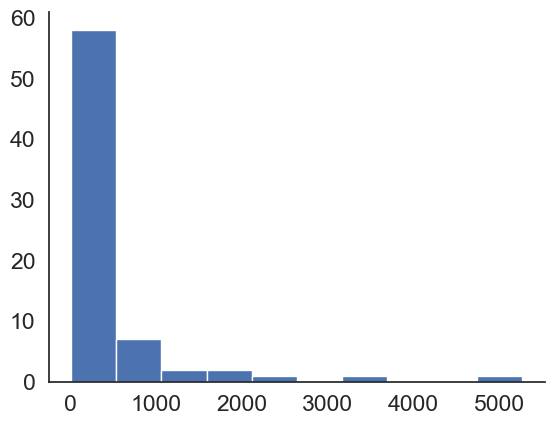

In [26]:
plt.hist(Info_2)
plt.show()

Low information cells: 10,66,42,40,30

High information cells: 71,62,0,1,26

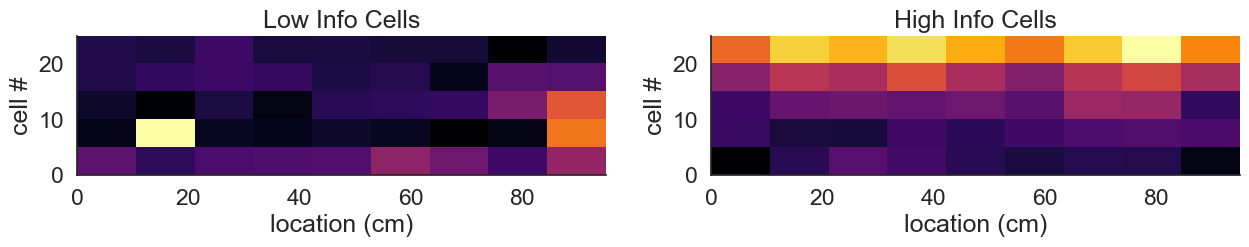

In [27]:
Low_Info_Index = [10,66,42,40,30]
High_Info_Index = [71,62,0,1,26]

fig = plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.imshow(firing_rate_maps[Low_Info_Index], cmap='inferno', extent = [0, tracklength, 0, 25])
plt.xlabel('location (cm)')
plt.ylabel('cell #')
plt.title('Low Info Cells')

plt.subplot(1,2,2)
plt.imshow(firing_rate_maps[High_Info_Index], cmap='inferno', extent = [0, tracklength, 0, 25])
plt.xlabel('location (cm)')
plt.ylabel('cell #')
plt.title('High Info Cells')

plt.show()
plt.close()